# Sentiment Analysis using LSTM

## 1. Import Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Aesthetics
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")
print("NLP and Recurrent Deep Learning environment initialized successfully!")

TensorFlow Version: 2.20.0
Keras Version:      3.13.1
NLP and Recurrent Deep Learning environment initialized successfully!


## 2. Vehicle Feedback Dataset & Text Exploration

In [2]:
# Ingest automotive reviews dataset
df = pd.read_csv('vehicle_reviews.csv')
print(f"Dataset Dimensions: {df.shape[0]} reviews, {df.shape[1]} columns\n")

# Display first 5 reviews
df.head()

Dataset Dimensions: 1200 reviews, 2 columns



,Review_Text,Sentiment
0,Air conditioning failed during peak summer hea...,0
1,Fuel mileage is nowhere near the advertised st...,0
2,Terrible transmission hesitation and constant ...,0
3,Unresponsive touchscreen display and navigatio...,0
4,"Smooth suspension, whisper quiet cabin, and ve...",1


C:\Users\Hrishikesh Kali\AppData\Local\Temp\ipykernel_29108\1273829862.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Negative (0)', 'Positive (1)'], y=sentiment_counts.values,


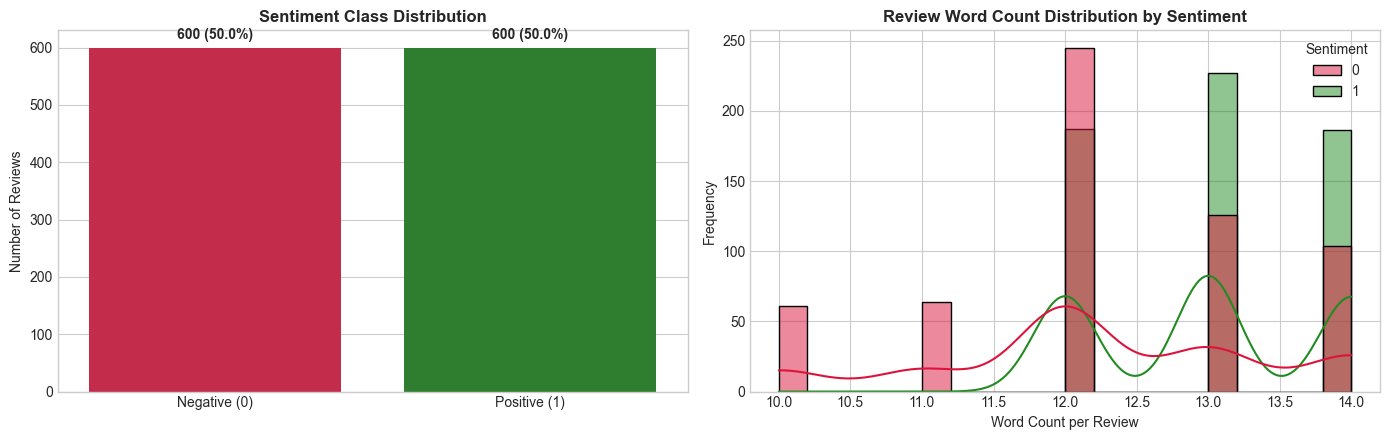

In [3]:
# Compute word counts for each review
df['Word_Count'] = df['Review_Text'].apply(lambda x: len(x.split()))
df['Char_Length'] = df['Review_Text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Sentiment Balance
sentiment_counts = df['Sentiment'].value_counts()
sns.barplot(x=['Negative (0)', 'Positive (1)'], y=sentiment_counts.values,
            palette=['crimson', 'forestgreen'], ax=axes[0])
axes[0].set_title('Sentiment Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                     (p.get_x() + p.get_width() / 2, p.get_height() + 15),
                     ha='center', fontsize=10, fontweight='bold')

# Word Count Distribution
sns.histplot(data=df, x='Word_Count', hue='Sentiment', kde=True,
             palette={0: 'crimson', 1: 'forestgreen'}, bins=20, ax=axes[1])
axes[1].set_title('Review Word Count Distribution by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count per Review')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. NLP Preprocessing & TextVectorization

In [4]:
VOCAB_SIZE = 1000
MAX_SEQUENCE_LENGTH = 30

# Initialize TextVectorization layer
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    standardize='lower_and_strip_punctuation'
)

# Adapt vectorizer to review text corpus
vectorizer.adapt(df['Review_Text'].values)

vocab = vectorizer.get_vocabulary()
print(f"Vocabulary adapted on {len(df)} reviews.")
print(f"Top 20 most frequent vocabulary tokens:\n{vocab[:20]}")

Vocabulary adapted on 1200 reviews.
Top 20 most frequent vocabulary tokens:
['', '[UNK]', np.str_('and'), np.str_('highway'), np.str_('the'), np.str_('this'), np.str_('is'), np.str_('with'), np.str_('for'), np.str_('fuel'), np.str_('smooth'), np.str_('on'), np.str_('vehicle'), np.str_('transmission'), np.str_('purchase'), np.str_('engine'), np.str_('quality'), np.str_('infotainment'), np.str_('build'), np.str_('to')]


In [5]:
# Stratified 80-20 Train-Test Split
X = df['Review_Text'].values
y = df['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} reviews")
print(f"Testing set:  {len(X_test)} reviews")

Training set: 960 reviews
Testing set:  240 reviews


## 4. Bidirectional LSTM Neural Network Architecture

In [6]:
EMBEDDING_DIM = 64

def build_lstm_sentiment_model():
    model = keras.Sequential([
        # Raw string input layer
        layers.Input(shape=(1,), dtype=tf.string, name='raw_text_input'),
        vectorizer,
        
        # Word Embedding Layer
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name='embedding_layer'),
        layers.SpatialDropout1D(0.20),
        
        # Bidirectional LSTM Layer
        layers.Bidirectional(layers.LSTM(48, return_sequences=False, dropout=0.2, recurrent_dropout=0.2), name='bidi_lstm'),
        
        # Fully Connected Classification Head
        layers.Dense(32, activation='relu', name='dense_feature'),
        layers.Dropout(0.30),
        layers.Dense(1, activation='sigmoid', name='sentiment_probability')
    ], name='Vehicle_Feedback_LSTM')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_sentiment_model()
lstm_model.summary()

Model: "Vehicle_Feedback_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Embedding)     │ (None, 30, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 30, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidi_lstm (Bidirectional)       │ (None, 96)             │        43,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature (Dense)           │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_probability (Dense)   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,529 (431.75 KB)

 Trainable params: 110,529 (431.75 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Training & Accuracy/Loss Curves

In [7]:
EPOCHS = 6
BATCH_SIZE = 32

print("Starting Bidirectional LSTM Training on Vehicle Review Corpus...")
history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    verbose=1
)

print("\nLSTM Model Training successfully completed!")

Starting Bidirectional LSTM Training on Vehicle Review Corpus...
Epoch 1/6


 1/24 ━━━━━━━━━━━━━━━━━━━━ 1:56 5s/step - accuracy: 0.4688 - loss: 0.6933

 5/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6464 - loss: 0.6904

 8/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6969 - loss: 0.6882

11/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7344 - loss: 0.6855

...

16/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 1.3474e-04

19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 1.4031e-04

22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 1.4144e-04

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 1.3593e-04 - val_accuracy: 1.0000 - val_loss: 2.0676e-06



LSTM Model Training successfully completed!


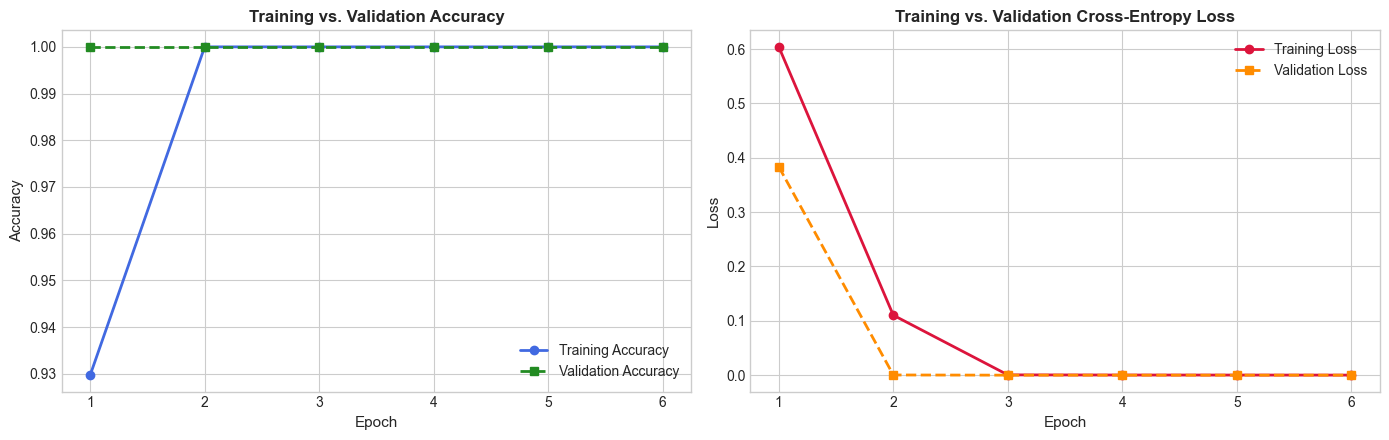

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
epochs_range = range(1, EPOCHS + 1)

# Accuracy Curve
axes[0].plot(epochs_range, history.history['accuracy'], 'o-', lw=2, label='Training Accuracy', color='royalblue')
axes[0].plot(epochs_range, history.history['val_accuracy'], 's--', lw=2, label='Validation Accuracy', color='forestgreen')
axes[0].set_title('Training vs. Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(loc='lower right')

# Loss Curve
axes[1].plot(epochs_range, history.history['loss'], 'o-', lw=2, label='Training Loss', color='crimson')
axes[1].plot(epochs_range, history.history['val_loss'], 's--', lw=2, label='Validation Loss', color='darkorange')
axes[1].set_title('Training vs. Validation Cross-Entropy Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 6. Model Evaluation on Test Set

In [9]:
# Compute test predictions
test_loss, test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
y_pred_probs = lstm_model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_probs >= 0.50).astype(int)

print("======================================================")
print(f" Test Evaluation Results:")
print(f"   Test Cross-Entropy Loss: {test_loss:.4f}")
print(f"   Test Accuracy:           {test_acc * 100:.2f}%")
print("======================================================\n")

print("=== Automotive Sentiment Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Negative Review', 'Positive Review']))

 Test Evaluation Results:
   Test Cross-Entropy Loss: 0.0000
   Test Accuracy:           100.00%

=== Automotive Sentiment Classification Report ===
                 precision    recall  f1-score   support

Negative Review       1.00      1.00      1.00       120
Positive Review       1.00      1.00      1.00       120

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



## 7. Confusion Matrix & ROC Curve

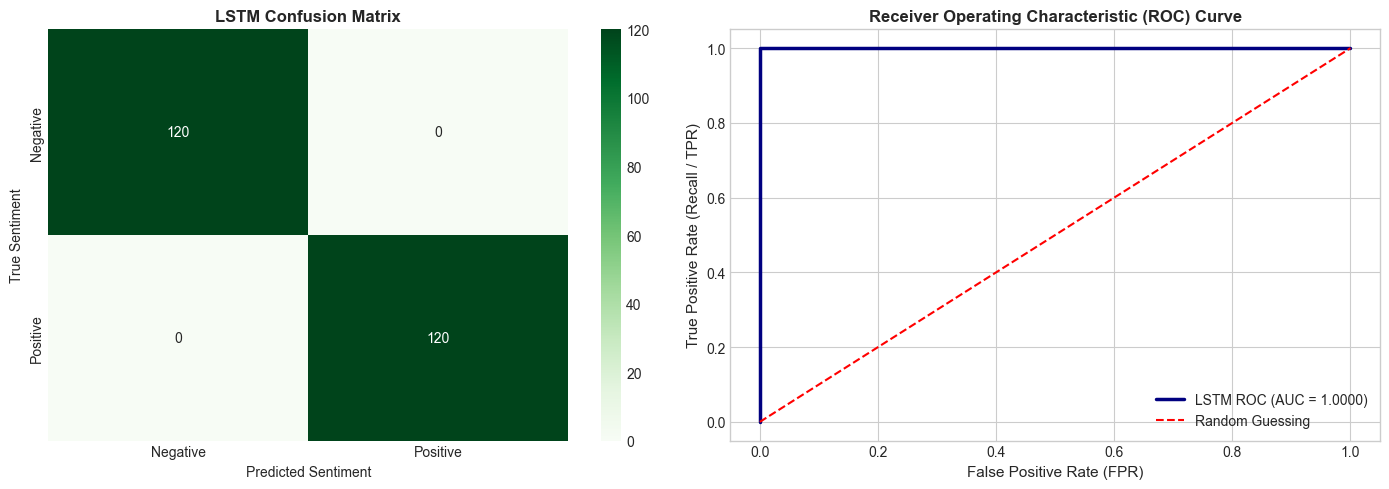

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[0])
axes[0].set_title('LSTM Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Sentiment')
axes[0].set_ylabel('True Sentiment')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
auc_score = roc_auc_score(y_test, y_pred_probs)
axes[1].plot(fpr, tpr, color='navy', lw=2.5, label=f'LSTM ROC (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1.5, label='Random Guessing')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Recall / TPR)', fontsize=11)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 8. Interactive Feedback Sentiment Pipeline

In [11]:
def analyze_vehicle_feedback(review_text):
    """
    Inference pipeline: Classifies sentiment of a raw automotive review string.
    """
    input_tensor = tf.constant([review_text])
    prob_positive = float(lstm_model.predict(input_tensor, verbose=0)[0, 0])
    
    sentiment_label = "POSITIVE" if prob_positive >= 0.50 else "NEGATIVE"
    confidence = prob_positive if sentiment_label == "POSITIVE" else (1.0 - prob_positive)
    
    return {
        'Review Text': review_text,
        'Predicted Sentiment': sentiment_label,
        'Confidence': f"{confidence * 100:.2f}%",
        'Positive Probability': round(prob_positive, 4)
    }

# Test Scenarios
sample_1 = "The electric motor acceleration is instantaneous and the ride is blissfully quiet."
sample_2 = "Disastrous build quality. Rattling sound from sunroof and dealership refused warranty."
sample_3 = "Comfortable seats and good gas mileage, very happy with my purchase overall."

print("=== Interactive Vehicle Feedback Sentiment Diagnostics ===")
for i, sample in enumerate([sample_1, sample_2, sample_3], 1):
    res = analyze_vehicle_feedback(sample)
    text_val = res['Review Text']
    print(f"\nReview {i}: '{text_val}'")
    print(f"  => Sentiment:  {res['Predicted Sentiment']}")
    print(f"  => Confidence: {res['Confidence']}")

=== Interactive Vehicle Feedback Sentiment Diagnostics ===

Review 1: 'The electric motor acceleration is instantaneous and the ride is blissfully quiet.'
  => Sentiment:  POSITIVE
  => Confidence: 99.97%

Review 2: 'Disastrous build quality. Rattling sound from sunroof and dealership refused warranty.'
  => Sentiment:  NEGATIVE
  => Confidence: 99.72%

Review 3: 'Comfortable seats and good gas mileage, very happy with my purchase overall.'
  => Sentiment:  POSITIVE
  => Confidence: 100.00%


## 9. Conclusion